In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('cookie_cats.csv')

# Check data shape and inspect the first 10 rows
print(f"Data loaded successfully! Shape: {df.shape}")
df.head(10)

Data loaded successfully! Shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


Players per group:
version
gate_30    44700
gate_40    45489
Name: userid, dtype: int64

Balance ratio: 98.27%

Players who never played a single round: 3994
This is 4.43% of all users

Breakdown by group:
version
gate_30    1937
gate_40    2057
Name: userid, dtype: int64


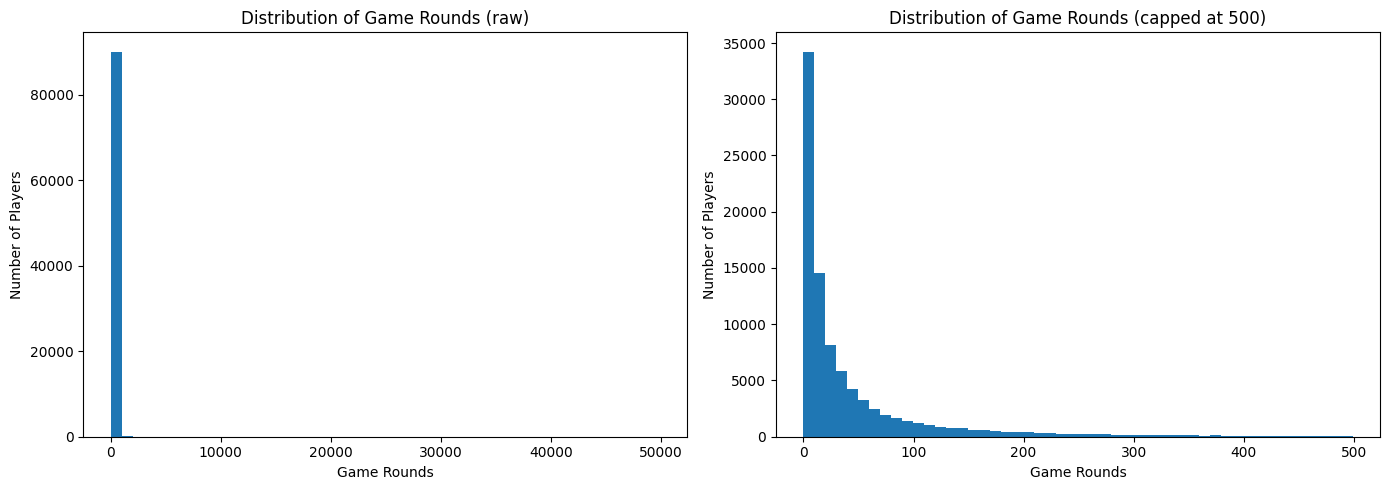


Correlation between Day 1 and Day 7 retention:
             retention_1  retention_7
retention_1        1.000        0.327
retention_7        0.327        1.000


In [14]:
import matplotlib.pyplot as plt

# Group size balance
group_sizes = df.groupby('version')['userid'].count()
print("Players per group:")
print(group_sizes)
print(f"\nBalance ratio: {group_sizes.min() / group_sizes.max():.2%}")

# Zero-round players
zero_round = df[df['sum_gamerounds'] == 0]
print(f"\nPlayers who never played a single round: {len(zero_round)}")
print(f"This is {len(zero_round) / len(df) * 100:.2f}% of all users")
print("\nBreakdown by group:")
print(zero_round.groupby('version')['userid'].count())

# Distribution of game rounds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['sum_gamerounds'].plot(
    kind='hist', bins=50, ax=axes[0],
    title='Distribution of Game Rounds (raw)',
    xlabel='Game Rounds', ylabel='Number of Players'
)

df[df['sum_gamerounds'] < 500]['sum_gamerounds'].plot(
    kind='hist', bins=50, ax=axes[1],
    title='Distribution of Game Rounds (capped at 500)',
    xlabel='Game Rounds', ylabel='Number of Players'
)

plt.tight_layout()
plt.show()

# Retention correlation
print("\nCorrelation between Day 1 and Day 7 retention:")
print(df[['retention_1', 'retention_7']].corr().round(3))

In [20]:
def find_outliers(data, top_n=5):
    # Sort data by game rounds in descending order to find top players
    top_players = data.sort_values(by='sum_gamerounds', ascending=False).head(top_n)

    print(f"Top {top_n} players by game rounds played:")
    print(top_players[['userid', 'version', 'sum_gamerounds']])

    # Calculate baseline descriptive statistics
    print("\nGeneral summary statistics for game rounds:")
    print(data['sum_gamerounds'].describe())

# Call the function for our dataframe
find_outliers(df)

Top 5 players by game rounds played:
        userid  version  sum_gamerounds
57702  6390605  gate_30           49854
7912    871500  gate_30            2961
29417  3271615  gate_40            2640
43671  4832608  gate_30            2438
48188  5346171  gate_40            2294

General summary statistics for game rounds:
count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


In [21]:
def remove_outliers_and_check(data, threshold=40000):
    initial_count = len(data)

    # Step 1: Remove bot/tracking error (rounds above threshold)
    data = data[data['sum_gamerounds'] < threshold]
    removed_outliers = initial_count - len(data)

    # Step 2: Remove zero-round players (installed but never played)
    data = data[data['sum_gamerounds'] > 0]
    removed_zero = initial_count - removed_outliers - len(data)

    print(f"Removed bot/outlier rows: {removed_outliers}")
    print(f"Removed zero-round players: {removed_zero}")
    print(f"Final dataset size: {len(data)} players")
    print("\nUpdated summary statistics for game rounds:")
    print(data['sum_gamerounds'].describe())

    return data

df_cleaned = remove_outliers_and_check(df)

Removed bot/outlier rows: 1
Removed zero-round players: 3994
Final dataset size: 86194 players

Updated summary statistics for game rounds:
count    86194.000000
mean        53.698297
std        104.425174
min          1.000000
25%          6.000000
50%         18.000000
75%         54.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64


In [22]:
find_outliers(df_cleaned)

Top 5 players by game rounds played:
        userid  version  sum_gamerounds
7912    871500  gate_30            2961
29417  3271615  gate_40            2640
43671  4832608  gate_30            2438
48188  5346171  gate_40            2294
46344  5133952  gate_30            2251

General summary statistics for game rounds:
count    86194.000000
mean        53.698297
std        104.425174
min          1.000000
25%          6.000000
50%         18.000000
75%         54.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64


In [23]:
# Find users who skipped Day 1 but returned on Day 7
sleeping_users = df_cleaned[
    (df_cleaned['retention_1'] == False) &
    (df_cleaned['retention_7'] == True)
]

print(f"Players who missed Day 1 but returned on Day 7: {len(sleeping_users)}")
print(f"This is {len(sleeping_users) / len(df_cleaned) * 100:.2f}% of all users")
print("\nBreakdown by group:")
print(sleeping_users.groupby('version')['userid'].count())

Players who missed Day 1 but returned on Day 7: 3574
This is 4.15% of all users

Breakdown by group:
version
gate_30    1810
gate_40    1764
Name: userid, dtype: int64


In [24]:
def calculate_retention(data):
    # Group by version and calculate mean for retention metrics
    retention_stats = data.groupby('version')[['retention_1', 'retention_7']].mean()

    # Convert to percentages for readability
    retention_stats_pct = retention_stats * 100

    print("Retention rates for each group (in %):")
    print(retention_stats_pct.round(2))

    return retention_stats_pct

# Call the function for cleaned data
retention_results = calculate_retention(df_cleaned)

Retention rates for each group (in %):
         retention_1  retention_7
version                          
gate_30        46.75        19.84
gate_40        46.22        19.03


In [28]:
import numpy as np

def run_bootstrap_7(data, iterations=10000):
    bootstrap_means = []

    # Loop to generate random resamples with replacement
    for i in range(iterations):
        # sample(frac=1, replace=True) creates a new resample of the same size
        boot_sample = data.sample(frac=1, replace=True)

        # Calculate mean retention_7 for both groups in this resample
        group_means = boot_sample.groupby('version')['retention_7'].mean()
        bootstrap_means.append(group_means)

    # Convert results into a convenient DataFrame
    bootstrap_df = pd.DataFrame(bootstrap_means)

    # Calculate the percentage difference column between groups
    bootstrap_df['diff'] = (bootstrap_df['gate_30'] - bootstrap_df['gate_40']) * 100

    # Calculate the % of cases where gate_30 performed better than gate_40
    prob_gate_30_is_better = (bootstrap_df['diff'] > 0).mean() * 100

    print(f"Probability that Day 7 Retention is better at Level 30: {prob_gate_30_is_better:.2f}%")

    return bootstrap_df

# Run bootstrapping
boot_results = run_bootstrap_7(df_cleaned)

Probability that Day 7 Retention is better at Level 30: 99.87%


In [26]:
def calculate_daily_rounds(data):
    # Create a new column: divide total rounds by 14 days of the experiment
    data = data.copy()  # Make a copy to avoid Pandas SettingWithCopyWarning
    data['daily_rounds'] = data['sum_gamerounds'] / 14

    # Group by version and calculate the mean of daily rounds
    avg_daily_rounds = data.groupby('version')['daily_rounds'].mean()

    print("Mean daily game rounds played per player:")
    print(avg_daily_rounds.round(2))

    # Check the median since the mean can be heavily skewed by top active players
    median_daily_rounds = data.groupby('version')['daily_rounds'].median()
    print("\nMedian daily game rounds played (typical player):")
    print(median_daily_rounds.round(2))

# Call the function for the cleaned dataset
calculate_daily_rounds(df_cleaned)

Mean daily game rounds played per player:
version
gate_30    3.83
gate_40    3.84
Name: daily_rounds, dtype: float64

Median daily game rounds played (typical player):
version
gate_30    1.29
gate_40    1.29
Name: daily_rounds, dtype: float64


In [27]:
def calculate_day_to_gate(data):
    # Filter users who actually reached or passed the gate level
    reach_30_users = data[(data['version'] == 'gate_30') & (data['sum_gamerounds'] >= 30)].copy()
    reach_40_users = data[(data['version'] == 'gate_40') & (data['sum_gamerounds'] >= 40)].copy()

    # Calculate player gaming speed (rounds per day) for each user
    reach_30_users['speed'] = reach_30_users['sum_gamerounds'] / 14
    reach_40_users['speed'] = reach_40_users['sum_gamerounds'] / 14

    # Calculate the estimated day when they hit their 30th or 40th round
    reach_30_users['day_reached'] = 30 / reach_30_users['speed']
    reach_40_users['day_reached'] = 40 / reach_40_users['speed']

    print("Mean day of reaching the gate:")
    print(f"Group gate_30: Day {reach_30_users['day_reached'].mean():.1f}")
    print(f"Group gate_40: Day {reach_40_users['day_reached'].mean():.1f}")

    print("\nMedian day of reaching the gate (typical player):")
    print(f"Group gate_30: Day {reach_30_users['day_reached'].median():.1f}")
    print(f"Group gate_40: Day {reach_40_users['day_reached'].median():.1f}")

# Call the function for the cleaned dataset
calculate_day_to_gate(df_cleaned)

Mean day of reaching the gate:
Group gate_30: Day 6.4
Group gate_40: Day 6.6

Median day of reaching the gate (typical player):
Group gate_30: Day 5.8
Group gate_40: Day 6.1
